# Stochastic Inventory Optimisation for Ecommerce

## A Markov-chain and Monte Carlo study of one category-neutral SKU

This notebook follows the full argument behind the GitHub report. The case is an illustrative ecommerce fulfilment centre replenishing one generic non-perishable SKU from a nearby central warehouse. The category is intentionally unspecified, and the inputs are not company observations.

**Question:** Which `(s, S)` policy minimises stationary long-run expected daily cost, how does the answer respond to different demand distributions, and which policy is cheapest under an illustrative 97% fill-rate target?

## Mathematical route

The analysis uses undergraduate ideas from discrete probability, linear algebra, stochastic processes, statistics, and finite optimisation:

1. represent inventory as a finite Markov chain;
2. calculate its stationary distribution;
3. weight state-demand costs by stationary probabilities;
4. enumerate 180 feasible policies and audit the artificial upper boundaries;
5. check the implementation with warm-up-adjusted Monte Carlo simulation;
6. impose an illustrative 97% fill-rate constraint and inspect the cost-service Pareto frontier;
7. repeat the optimisation under four different demand distributions.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import SVG, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from inventory_model import (
    BASELINE_COSTS,
    BASELINE_DEMAND,
    CASE_STUDY,
    POLICY_GRID_MAX_ORDER_UP_TO,
    POLICY_GRID_MAX_REORDER_POINT,
    POLICY_GRID_MIN_REORDER_POINT,
    SERVICE_FILL_RATE_TARGET,
    Policy,
    build_transition_matrix,
    markov_policy_metrics,
    pareto_frontier,
    select_policy,
    simulate_policy,
    stationary_distribution,
)

pd.set_option("display.max_columns", 30)
CASE_STUDY

{'business': 'illustrative ecommerce fulfilment centre',
 'product_scope': 'one generic non-perishable SKU',
 'category_status': 'category-neutral by design',
 'replenishment_source': 'nearby central warehouse',
 'data_status': 'illustrative scenario; not calibrated to company data'}

## 1. Assumptions

The model reviews stock daily, assumes same-day transfer from the central warehouse, and treats unmet demand as lost sales. These choices make the first model finite and inspectable. They are modelling assumptions, not facts about every ecommerce operation.

In [2]:
demand = pd.DataFrame(
    {
        "daily_demand": BASELINE_DEMAND.values,
        "probability": BASELINE_DEMAND.probabilities,
    }
)
demand["weighted_demand"] = demand["daily_demand"] * demand["probability"]
expected_demand = demand["weighted_demand"].sum()
demand_variance = (
    ((demand["daily_demand"] - expected_demand) ** 2) * demand["probability"]
).sum()
demand_display = demand.copy()
demand_display["probability"] = demand_display["probability"].map("{:.0%}".format)
demand_display["weighted_demand"] = demand_display["weighted_demand"].map("{:.3f}".format)
display(demand_display)
print(f"E[D] = {expected_demand:.2f} units; Var(D) = {demand_variance:.4f}")

pd.DataFrame(
    {
        "parameter": ["Fixed order cost K", "Unit order cost c", "Holding cost h", "Shortage cost p"],
        "value": [
            BASELINE_COSTS.order_fixed_cost,
            BASELINE_COSTS.order_unit_cost,
            BASELINE_COSTS.holding_cost,
            BASELINE_COSTS.shortage_cost,
        ],
    }
)

,daily_demand,probability,weighted_demand
0,0,5%,0.000
1,1,10%,0.100
2,2,20%,0.400
3,3,25%,0.750
4,4,20%,0.800
5,5,12%,0.600
6,6,8%,0.480


E[D] = 3.13 units; Var(D) = 2.4331


,parameter,value
0,Fixed order cost K,30.0
1,Unit order cost c,2.0
2,Holding cost h,1.0
3,Shortage cost p,8.0


## 2. State transition and one-day cost

For opening inventory `I_t`, the policy replenishes to `S` whenever `I_t <= s`. After demand `D_t`, the next state is

```text
I_(t+1) = max(I_t + Q_t - D_t, 0).
```

Daily cost combines the order setup charge, unit purchasing cost, ending-inventory holding cost, and shortage penalty. Under a fixed policy, the next state depends only on the current state and the new demand draw, so the process has the Markov property.

In [3]:
published_decisions = pd.read_csv(ROOT / "outputs" / "service_level_policy_summary.csv")
published_cost_choice = published_decisions.loc[
    published_decisions["minimum_fill_rate"] == 0
].iloc[0]
cost_policy = Policy(int(published_cost_choice["s"]), int(published_cost_choice["S"]))
transition = build_transition_matrix(cost_policy)
stationary = stationary_distribution(transition)

print("Transition shape:", transition.shape)
print("Maximum row-sum error:", np.abs(transition.sum(axis=1) - 1).max())
print("Stationary residual ||pi P - pi||_inf:", np.abs(stationary @ transition - stationary).max())

stationary_table = pd.DataFrame(
    {"opening_inventory": np.arange(len(stationary)), "stationary_probability": stationary}
)
stationary_display = stationary_table.copy()
stationary_display["stationary_probability"] = stationary_display["stationary_probability"].map("{:.2%}".format)
display(stationary_display)

Transition shape: (15, 15)
Maximum row-sum error: 0.0
Stationary residual ||pi P - pi||_inf: 1.67e-14


,opening_inventory,stationary_probability
0,0,20.26%
1,1,6.45%
2,2,6.48%
3,3,6.46%
4,4,6.49%
5,5,6.55%
6,6,6.46%
7,7,6.05%
8,8,6.92%
9,9,6.51%


## 3. Stationary long-run result

The stationary distribution gives the long-run proportion of days spent in each state. Weighting expected one-day outcomes by these probabilities produces deterministic finite-model metrics, evaluated numerically to a tolerance of `1e-14`.

In [4]:
exact_metrics = pd.Series(markov_policy_metrics(cost_policy), name="exact_result")
exact_metrics.to_frame().round(4)

,exact_result
average_daily_cost,19.4352
average_fixed_order_cost,6.0768
average_unit_order_cost,5.6717
average_holding_cost,5.3335
average_shortage_cost,2.3532
stockout_rate,0.1410
fill_rate,0.9060
average_ending_inventory,5.3335
average_order_quantity,2.8359
order_frequency,0.2026


## 4. Independent Monte Carlo check

The saved experiment uses 200 replications. Each replication discards 365 warm-up days before measuring the next 365 days. The warm-up prevents the chosen full-stock initial state from biasing a short measurement window.

In [5]:
decisions = pd.read_csv(ROOT / "outputs" / "service_level_policy_summary.csv")
validation_columns = [
    "decision_rule",
    "s",
    "S",
    "average_daily_cost",
    "simulation_average_daily_cost",
    "simulation_cost_95_ci_low",
    "simulation_cost_95_ci_high",
    "stockout_rate",
    "fill_rate",
]
validation = decisions[validation_columns].copy()
for column in [
    "average_daily_cost",
    "simulation_average_daily_cost",
    "simulation_cost_95_ci_low",
    "simulation_cost_95_ci_high",
]:
    validation[column] = validation[column].map("{:.4f}".format)
for column in ["stockout_rate", "fill_rate"]:
    validation[column] = validation[column].map("{:.2%}".format)
validation

,decision_rule,s,S,average_daily_cost,simulation_average_daily_cost,simulation_cost_95_ci_low,simulation_cost_95_ci_high,stockout_rate,fill_rate
0,minimum expected daily cost,0.0,14.0,19.4352,19.4512,19.4020,19.5004,14.10%,90.60%
1,minimum cost with fill rate >= 97%,2.0,15.0,19.7937,19.8076,19.7648,19.8504,4.70%,97.70%


,day,opening_inventory,demand,available_inventory,order_quantity,sales,ending_inventory,shortage,order_cost,holding_cost,shortage_cost,total_cost
0,1,5,3,5,0,3,2,0,0.0,2.0,0.0,2.0
1,2,2,3,2,0,2,0,1,0.0,0.0,8.0,8.0
2,3,0,4,14,14,4,10,0,58.0,10.0,0.0,68.0
3,4,10,5,10,0,5,5,0,0.0,5.0,0.0,5.0
4,5,5,2,5,0,2,3,0,0.0,3.0,0.0,3.0
5,6,3,1,3,0,1,2,0,0.0,2.0,0.0,2.0
6,7,2,1,2,0,1,1,0,0.0,1.0,0.0,1.0
7,8,1,6,1,0,1,0,5,0.0,0.0,40.0,40.0
8,9,0,6,14,14,6,8,0,58.0,8.0,0.0,66.0
9,10,8,2,8,0,2,6,0,0.0,6.0,0.0,6.0


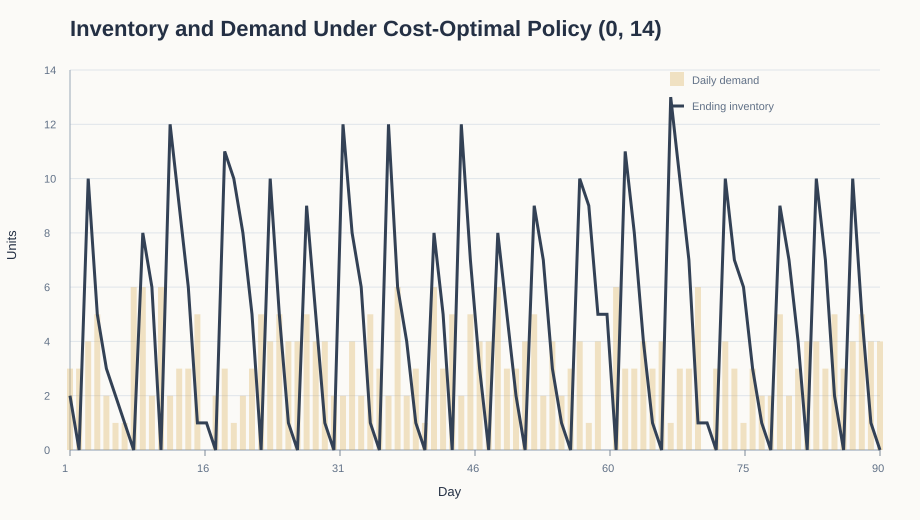

In [6]:
trace = simulate_policy(cost_policy, periods=20, warmup_periods=365, seed=7)
display(trace.head(10))
display(SVG(filename=str(ROOT / "outputs" / "figures" / "inventory_path.svg")))

## 5. Exhaustive policy search

The feasible grid contains 180 policies: `s` ranges from 0 to 8, and `S` ranges from `s + 1` to 24. This includes every integer pair satisfying the standard requirement `S > s` inside the rectangle. Reorder point zero is the natural physical lower bound. The program rejects publication if any selected baseline, demand, service, or cost-sensitivity policy touches either artificial upper bound. The largest selected values are `s=3` and `S=21`, leaving margins of 5 and 3 units. Thus `(0, 14)` is the exact minimum **within an audited finite grid**, not a claim over every possible business environment.

,s,S,average_daily_cost,stockout_rate,fill_rate,average_ending_inventory
0,0,14,19.44,14.10%,90.60%,5.33
1,1,14,19.44,9.21%,94.76%,5.70
2,0,15,19.44,13.25%,91.17%,5.82
3,1,15,19.45,8.60%,95.11%,6.19
4,0,13,19.50,15.10%,89.93%,4.85
5,1,13,19.50,9.90%,94.37%,5.21
6,0,16,19.51,12.49%,91.67%,6.31
7,1,16,19.52,8.08%,95.40%,6.69
8,0,17,19.62,11.81%,92.12%,6.79
9,1,17,19.64,7.62%,95.66%,7.18


,cost per day
average_fixed_order_cost,6.0768
average_unit_order_cost,5.6717
average_holding_cost,5.3335
average_shortage_cost,2.3532
average_daily_cost,19.4352


,analysis,scenario,s,S,distance_to_max_s,distance_to_max_S,touches_upper_boundary
0,baseline cost optimum,baseline_mixed,0,14,8,10,False
1,baseline 97% fill-rate choice,baseline_mixed,2,15,6,9,False
2,cost sensitivity optimum,holding=0.5; shortage=4,0,19,8,5,False
3,cost sensitivity optimum,holding=0.5; shortage=8,1,20,7,4,False
4,cost sensitivity optimum,holding=0.5; shortage=16,2,21,6,3,False
5,cost sensitivity optimum,holding=1; shortage=4,0,13,8,11,False
6,cost sensitivity optimum,holding=1; shortage=8,0,14,8,10,False
7,cost sensitivity optimum,holding=1; shortage=16,2,15,6,9,False
8,cost sensitivity optimum,holding=2; shortage=4,0,9,8,15,False
9,cost sensitivity optimum,holding=2; shortage=8,0,10,8,14,False


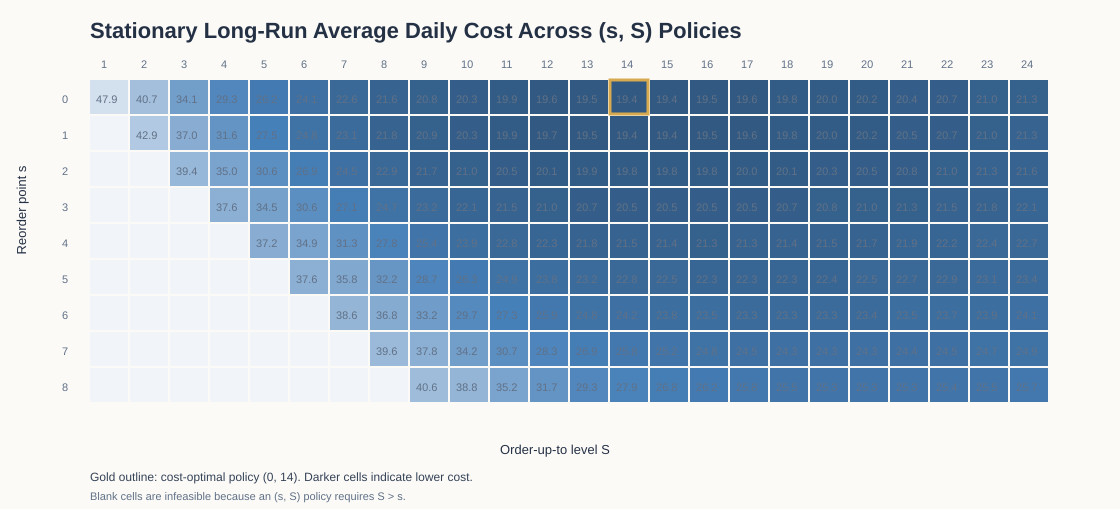

In [7]:
evaluation = pd.read_csv(ROOT / "outputs" / "policy_evaluation_summary.csv")
columns = ["s", "S", "average_daily_cost", "stockout_rate", "fill_rate", "average_ending_inventory"]
top_policies = evaluation.loc[:9, columns].copy()
top_policies["average_daily_cost"] = top_policies["average_daily_cost"].map("{:.2f}".format)
top_policies["stockout_rate"] = top_policies["stockout_rate"].map("{:.2%}".format)
top_policies["fill_rate"] = top_policies["fill_rate"].map("{:.2%}".format)
top_policies["average_ending_inventory"] = top_policies["average_ending_inventory"].map("{:.2f}".format)
display(top_policies)
cost_components = evaluation.loc[
    (evaluation["s"] == cost_policy.reorder_point)
    & (evaluation["S"] == cost_policy.order_up_to),
    [
        "average_fixed_order_cost",
        "average_unit_order_cost",
        "average_holding_cost",
        "average_shortage_cost",
        "average_daily_cost",
    ],
].T
cost_components.columns = ["cost per day"]
display(cost_components.round(4))
boundary_audit = pd.read_csv(ROOT / "outputs" / "search_boundary_audit.csv")
display(boundary_audit)
display(SVG(filename=str(ROOT / "outputs" / "figures" / "policy_cost_heatmap.svg")))

## 6. Service constraint and Pareto frontier

Cost alone selects `(0, 14)`, with a fill rate of `90.60%`. If the fulfilment centre adopts an illustrative target of at least `97%`, the feasible policy set changes and `(2, 15)` becomes the minimum-cost choice. It costs `0.3585` more per day (`1.84%`) and lowers stockout probability by `9.40` percentage points. The threshold is a scenario input, not an industry benchmark.

Cost optimum: (0, 14)
97% fill-rate choice: (2, 15)


,s,S,average_daily_cost,stockout_rate,fill_rate
0,0,14,19.44,14.10%,90.60%
1,1,14,19.44,9.21%,94.76%
2,1,15,19.45,8.60%,95.11%
3,1,16,19.52,8.08%,95.40%
4,1,17,19.64,7.62%,95.66%
5,2,15,19.79,4.70%,97.70%
6,2,16,19.85,4.39%,97.85%
7,2,17,19.95,4.13%,97.98%
8,2,18,20.10,3.90%,98.10%
9,2,19,20.29,3.69%,98.20%


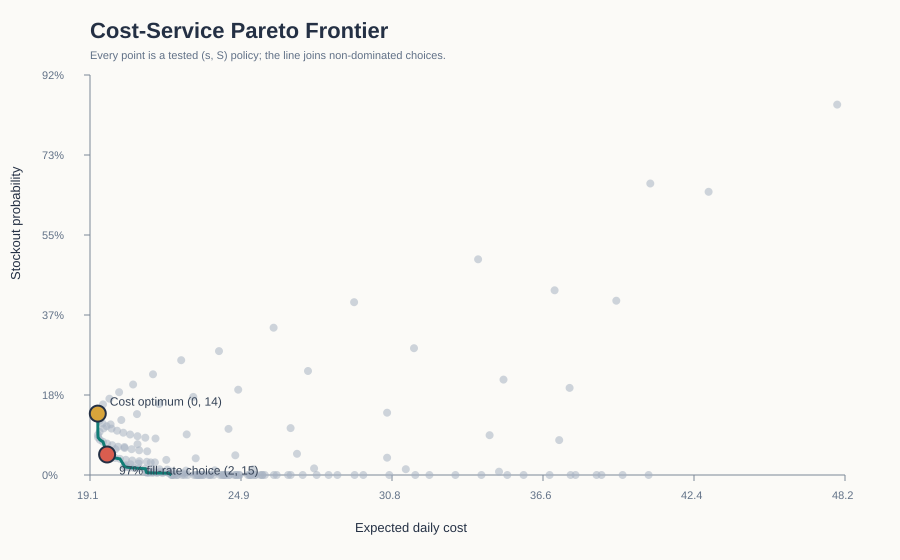

In [8]:
exact_summary = evaluation[["s", "S", "average_daily_cost", "stockout_rate", "fill_rate"]]
selected_cost = select_policy(exact_summary)
selected_service = select_policy(exact_summary, minimum_fill_rate=SERVICE_FILL_RATE_TARGET)
frontier = pareto_frontier(exact_summary)

print("Cost optimum:", (int(selected_cost["s"]), int(selected_cost["S"])))
print("97% fill-rate choice:", (int(selected_service["s"]), int(selected_service["S"])))
frontier_display = frontier.copy()
frontier_display["average_daily_cost"] = frontier_display["average_daily_cost"].map("{:.2f}".format)
frontier_display["stockout_rate"] = frontier_display["stockout_rate"].map("{:.2%}".format)
frontier_display["fill_rate"] = frontier_display["fill_rate"].map("{:.2%}".format)
display(frontier_display)
display(SVG(filename=str(ROOT / "outputs" / "figures" / "cost_service_frontier.svg")))

## 7. Sensitivity analysis

The recommendation should move when the economics move. Increasing shortage cost makes earlier replenishment worthwhile; increasing holding cost supports a leaner stock target.

,holding_cost,shortage_cost,best_s,best_S,best_average_daily_cost,best_stockout_rate,best_fill_rate,best_average_ending_inventory
0,0.5,4.0,0,19,15.18,10.66%,92.89%,7.78
1,0.5,8.0,1,20,15.88,6.50%,96.30%,8.67
2,0.5,16.0,2,21,16.36,3.32%,98.38%,9.60
3,1.0,4.0,0,13,18.24,15.10%,89.93%,4.85
4,1.0,8.0,0,14,19.44,14.10%,90.60%,5.33
5,1.0,16.0,2,15,20.37,4.70%,97.70%,6.61
6,2.0,4.0,0,9,22.02,20.77%,86.20%,2.95
7,2.0,8.0,0,10,23.67,19.01%,87.31%,3.42
8,2.0,16.0,1,11,25.81,11.61%,93.38%,4.23


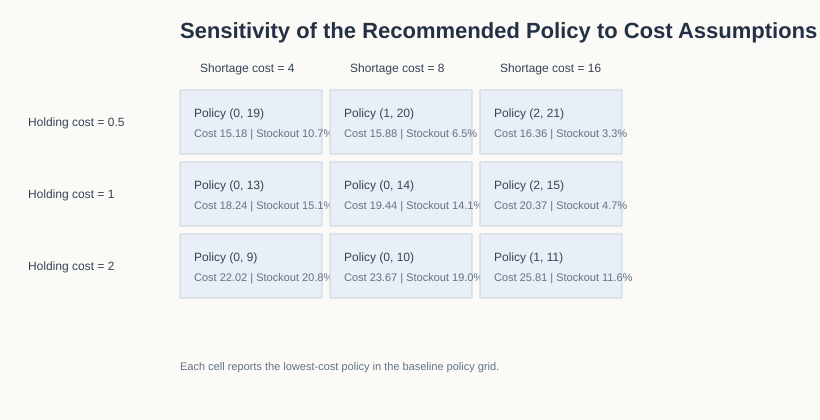

In [9]:
sensitivity = pd.read_csv(ROOT / "outputs" / "cost_sensitivity_summary.csv")
sensitivity_display = sensitivity.copy()
sensitivity_display["best_average_daily_cost"] = sensitivity_display["best_average_daily_cost"].map("{:.2f}".format)
sensitivity_display["best_stockout_rate"] = sensitivity_display["best_stockout_rate"].map("{:.2%}".format)
sensitivity_display["best_fill_rate"] = sensitivity_display["best_fill_rate"].map("{:.2%}".format)
sensitivity_display["best_average_ending_inventory"] = sensitivity_display["best_average_ending_inventory"].map("{:.2f}".format)
display(sensitivity_display)
display(SVG(filename=str(ROOT / "outputs" / "figures" / "cost_sensitivity.svg")))

## 8. Demand-distribution sensitivity

The execution manual asks for optimisation under different demand distributions. Four scenarios separate changes in average demand from changes in variability. Cost-only choices are `(0, 14)` for baseline and steady demand, `(1, 14)` under volatile demand, and `(2, 18)` during the promotion peak. The 97% choices are `(2, 15)`, `(1, 16)`, `(3, 16)`, and `(3, 18)` respectively. A fresh 180-policy enumeration produces every row.

,scenario,demand_mean,demand_variance,best_s,best_S,service_s,service_S,exact_average_daily_cost,exact_fill_rate,simulation_average_daily_cost
0,baseline_mixed,3.13,2.4331,0,14,2,15,19.44,90.60%,19.45
1,steady,3.00,0.9000,0,14,1,16,18.58,92.38%,18.55
2,volatile,3.00,4.6000,1,14,3,16,19.37,92.72%,19.36
3,promotion_peak,4.79,3.0659,2,18,3,18,25.72,95.49%,25.73


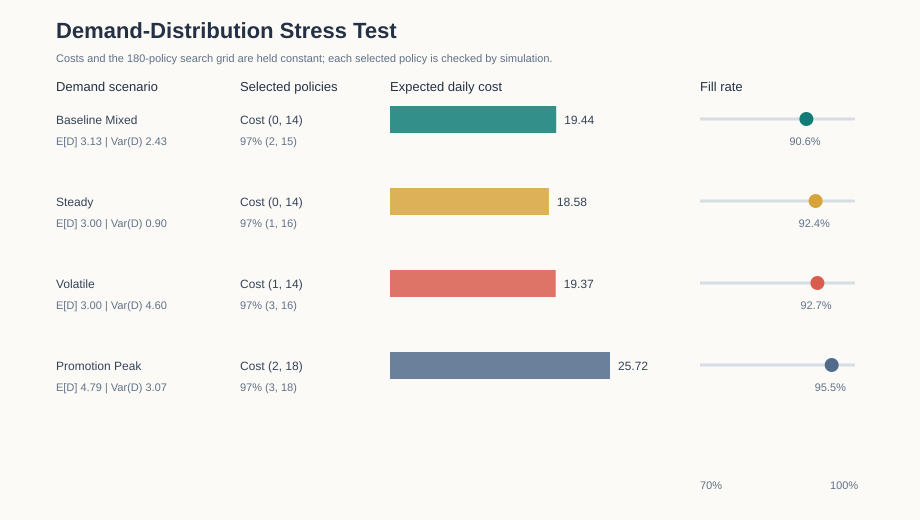

In [10]:
demand_scenarios = pd.read_csv(ROOT / "outputs" / "demand_scenario_summary.csv")
demand_display = demand_scenarios[
    [
        "scenario",
        "demand_mean",
        "demand_variance",
        "best_s",
        "best_S",
        "service_s",
        "service_S",
        "exact_average_daily_cost",
        "exact_fill_rate",
        "simulation_average_daily_cost",
    ]
].copy()
demand_display["exact_average_daily_cost"] = demand_display["exact_average_daily_cost"].map("{:.2f}".format)
demand_display["simulation_average_daily_cost"] = demand_display["simulation_average_daily_cost"].map("{:.2f}".format)
demand_display["exact_fill_rate"] = demand_display["exact_fill_rate"].map("{:.2%}".format)
display(demand_display)
display(SVG(filename=str(ROOT / "outputs" / "figures" / "demand_scenario_comparison.svg")))

## Conclusion and limits

The mathematical answer depends on the question. `(0, 14)` has the lowest stationary expected cost in the audited baseline grid. `(2, 15)` is the least-cost policy that meets the illustrative 97% fill-rate target under baseline demand. The cost gap between `(0, 14)` and `(1, 14)` is only about `0.0031` per day, so the exact ranking is sensitive to input calibration even though it is numerically well defined here. Distribution stress tests show that both the reorder point and target respond to variance and upward demand shifts.

The inputs are illustrative, demand is independent across days, lead time is treated as zero, shortages are lost sales, and only one SKU is modelled. A next empirical version should estimate demand from licensed transaction data and add positive lead time. AI supported review, debugging, prose editing, and visual QA; all numerical claims shown here come from executable code and tested outputs.